# NB_SoyCultivar200 — Soy Cultivar Classification

**Architecture:** Proposed1 — Custom Hybrid (Inception_cell Add + SkipConnection Concat + GAP)  
**Dataset:** SoyCultivar200 — 200 soy cultivar classes, 30 images each (Lower/Middle/Upper leaf)  
**Strategy:** Three sub-models (one per leaf position) → ensemble Final model  
**Augmentation:** None (baseline)  

> Dataset: https://data.mendeley.com/datasets/bshkvgbzpt/1 
> Run on Kaggle with T4 GPU.  
>
> **Flow:** Download → Split L/M/U → Train 3 sub-models → Ensemble final model → Evaluate  


In [1]:
!pip install kaggle tensorflow scikit-learn matplotlib seaborn pandas numpy Pillow tqdm psutil -q
print('All packages ready.')


All packages ready.


In [2]:
import os,math,random,json,warnings,zipfile,shutil,time,tracemalloc,psutil,gc
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from collections import defaultdict
from itertools import cycle
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,Conv2D,MaxPooling2D,GlobalAveragePooling2D,BatchNormalization,
    Dense,Dropout,Add,Concatenate,Multiply,Reshape,Layer
)
from tensorflow.keras.callbacks import LearningRateScheduler,EarlyStopping,ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,confusion_matrix,
    accuracy_score,precision_score,recall_score,f1_score,
    roc_curve,auc,precision_recall_curve,average_precision_score)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.manifold import TSNE

gpus = tf.config.list_physical_devices('GPU')
for g in gpus: tf.config.experimental.set_memory_growth(g,True)
print('TF '+tf.__version__+' | GPUs: '+str(len(gpus)))


TF 2.20.0 | GPUs: 1


In [3]:
NOTEBOOK_ID  = "NB_SoyCultivar200"
AUG_STRATEGY = "No Augmentation"
SEED=42; IMG_SIZE=(256,256); IMG_SHAPE=(256,256,3)
BATCH_SIZE=32; INITIAL_LR=1e-3; EPOCHS=60; DROPOUT_RATE=0.5
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

NUM_CULTIVARS = 200
TARGET_CLASSES = [str(i).zfill(3) for i in range(1, NUM_CULTIVARS+1)]
NUM_CLASSES    = len(TARGET_CLASSES)
CLASS_TO_IDX   = {c:i for i,c in enumerate(TARGET_CLASSES)}
IDX_TO_CLASS   = {i:c for i,c in enumerate(TARGET_CLASSES)}

KAGGLE_DATASETS = [
    ('dileshbisen123/plant-disease-dataset', 'plant-disease-dataset'),
]
VALID_EXTS = {'.jpg','.jpeg','.png','.bmp','.tif','.tiff'}

BASE_DIR    = os.path.join(os.path.expanduser('~'),'plant_project', NOTEBOOK_ID)
RAW_DIR     = os.path.join(os.path.expanduser('~'),'plant_project','raw')

LOWER_DIR   = os.path.join(BASE_DIR,'lower_dataset')
MIDDLE_DIR  = os.path.join(BASE_DIR,'middle_dataset')
UPPER_DIR   = os.path.join(BASE_DIR,'upper_dataset')

CKPT_DIR    = os.path.join(BASE_DIR,'checkpoints')
LOG_DIR     = os.path.join(BASE_DIR,'logs')
VIZ_DIR     = os.path.join(LOG_DIR,'visualizations')
for d in [BASE_DIR,RAW_DIR,LOWER_DIR,MIDDLE_DIR,UPPER_DIR,CKPT_DIR,LOG_DIR,VIZ_DIR]:
    os.makedirs(d, exist_ok=True)

def get_images(folder):
    if not os.path.isdir(folder): return []
    return [os.path.join(folder,f) for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in VALID_EXTS]

print('Config done: '+NOTEBOOK_ID)
print('Classes    : '+str(NUM_CLASSES)+' cultivars (001-200)')
print('Leaf views : Lower (L) | Middle (M) | Upper (U)')
print('Base dir   : '+BASE_DIR)


Config done: NB_SoyCultivar200
Classes    : 200 cultivars (001-200)
Leaf views : Lower (L) | Middle (M) | Upper (U)
Base dir   : /root/plant_project/NB_SoyCultivar200


In [4]:
KAGGLE_USERNAME="jyotiradityachillal"; KAGGLE_KEY="KGAT_bba51b5487bd42a6dc26ac9524d520f9"
import json as _j
kd=os.path.expanduser("~/.kaggle"); os.makedirs(kd,exist_ok=True)
with open(os.path.join(kd,"kaggle.json"),"w") as f:
    _j.dump({"username":KAGGLE_USERNAME,"key":KAGGLE_KEY},f)
os.chmod(os.path.join(kd,"kaggle.json"),0o600)
os.environ["KAGGLE_USERNAME"]=KAGGLE_USERNAME
os.environ["KAGGLE_KEY"]=KAGGLE_KEY
print("Kaggle credentials set.")


Kaggle credentials set.


In [5]:
orig=os.getcwd(); os.chdir(RAW_DIR)
for ds_slug,folder_name in KAGGLE_DATASETS:
    tf_dir=os.path.join(RAW_DIR,folder_name)
    zf=os.path.join(RAW_DIR,folder_name+'.zip')
    if os.path.isdir(tf_dir) and os.listdir(tf_dir):
        print('  Ready: '+folder_name+'/'); continue
    if not os.path.isfile(zf):
        print('Downloading '+ds_slug+' ...')
        os.system('kaggle datasets download -d '+ds_slug+' --quiet')
    with zipfile.ZipFile(zf,'r') as z: z.extractall(tf_dir)
    print('  Extracted: '+folder_name)
os.chdir(orig)

soy_root = None
for ds_slug,folder_name in KAGGLE_DATASETS:
    base = os.path.join(RAW_DIR,folder_name)
    for root,dirs,files in os.walk(base):
        if 'SoyCultivar200_dataset' in root or (
           len(dirs)>0 and all(d.isdigit() or (len(d)==3 and d.isdigit()) for d in dirs[:3])):
            soy_root = root; break
        if os.path.isdir(base):
            subdirs = [d for d in os.listdir(base) if os.path.isdir(os.path.join(base,d))]
            if len(subdirs)>10 and any(d.isdigit() for d in subdirs):
                soy_root=base; break
    if soy_root: break

if soy_root is None:
    for candidate in [
        os.path.join(RAW_DIR,'plant-disease-dataset','SoyCultivar200_dataset'),
        os.path.join(RAW_DIR,'plant-disease-dataset'),
    ]:
        if os.path.isdir(candidate): soy_root=candidate; break

print('Dataset root: '+str(soy_root))
if soy_root:
    sample_dirs = sorted(os.listdir(soy_root))[:5]
    print('First 5 class folders: '+str(sample_dirs))
    first_cls = os.path.join(soy_root, sample_dirs[0])
    print('Sample files: '+str(sorted(os.listdir(first_cls))[:6]))
else:
    print('ERROR: Could not locate dataset root. Check download.')


  Ready: plant-disease-dataset/
Dataset root: /root/plant_project/raw/plant-disease-dataset/SoyCultivar200/SoyCultivar200_dataset
First 5 class folders: ['001', '002', '003', '004', '005']
Sample files: ['001FZ_L_01.jpg', '001FZ_L_02.jpg', '001FZ_L_03.jpg', '001FZ_L_04.jpg', '001FZ_L_05.jpg', '001FZ_L_06.jpg']


## Dataset Split — Lower / Middle / Upper Leaf

The SoyCultivar200 dataset images are named: `001FZ_L_01.jpg` (Lower), `001FZ_M_01.jpg` (Middle), `001FZ_U_01.jpg` (Upper).
Each cultivar has 10 images per view = 30 images total per class.
We split them into three separate directories, one per leaf position.


In [6]:
skipped = []
total_copied = {'L':0,'M':0,'U':0}

for class_folder in sorted(os.listdir(soy_root)):
    class_path = os.path.join(soy_root, class_folder)
    if not os.path.isdir(class_path): continue

    for split_dir in [LOWER_DIR, MIDDLE_DIR, UPPER_DIR]:
        os.makedirs(os.path.join(split_dir, class_folder), exist_ok=True)

    for img_file in os.listdir(class_path):
        if os.path.splitext(img_file)[1].lower() not in VALID_EXTS:
            continue
        src = os.path.join(class_path, img_file)
        fname_upper = img_file.upper()

        if '_L_' in fname_upper:
            dst = os.path.join(LOWER_DIR, class_folder, img_file)
            key = 'L'
        elif '_M_' in fname_upper:
            dst = os.path.join(MIDDLE_DIR, class_folder, img_file)
            key = 'M'
        elif '_U_' in fname_upper:
            dst = os.path.join(UPPER_DIR, class_folder, img_file)
            key = 'U'
        else:
            skipped.append(img_file); continue

        if not os.path.exists(dst):
            shutil.copy2(src, dst)
        total_copied[key] += 1

print('Split complete:')
for label,key,split_dir in [('Lower (L)','L',LOWER_DIR),
                              ('Middle (M)','M',MIDDLE_DIR),
                              ('Upper (U)','U',UPPER_DIR)]:
    n_cls = len([d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir,d))])
    n_img = sum(len(get_images(os.path.join(split_dir,d)))
                for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir,d)))
    print('  '+label+': '+str(n_cls)+' classes, '+str(n_img)+' images  (expected '+str(n_cls*10)+')')

if skipped:
    print('WARNING: '+str(len(skipped))+' files skipped — no L/M/U in filename')
    for s in skipped[:5]: print('  '+s)


Split complete:
  Lower (L): 200 classes, 2000 images  (expected 2000)
  Middle (M): 200 classes, 2000 images  (expected 2000)
  Upper (U): 200 classes, 2000 images  (expected 2000)


## EDA — Sample Images per Leaf Position


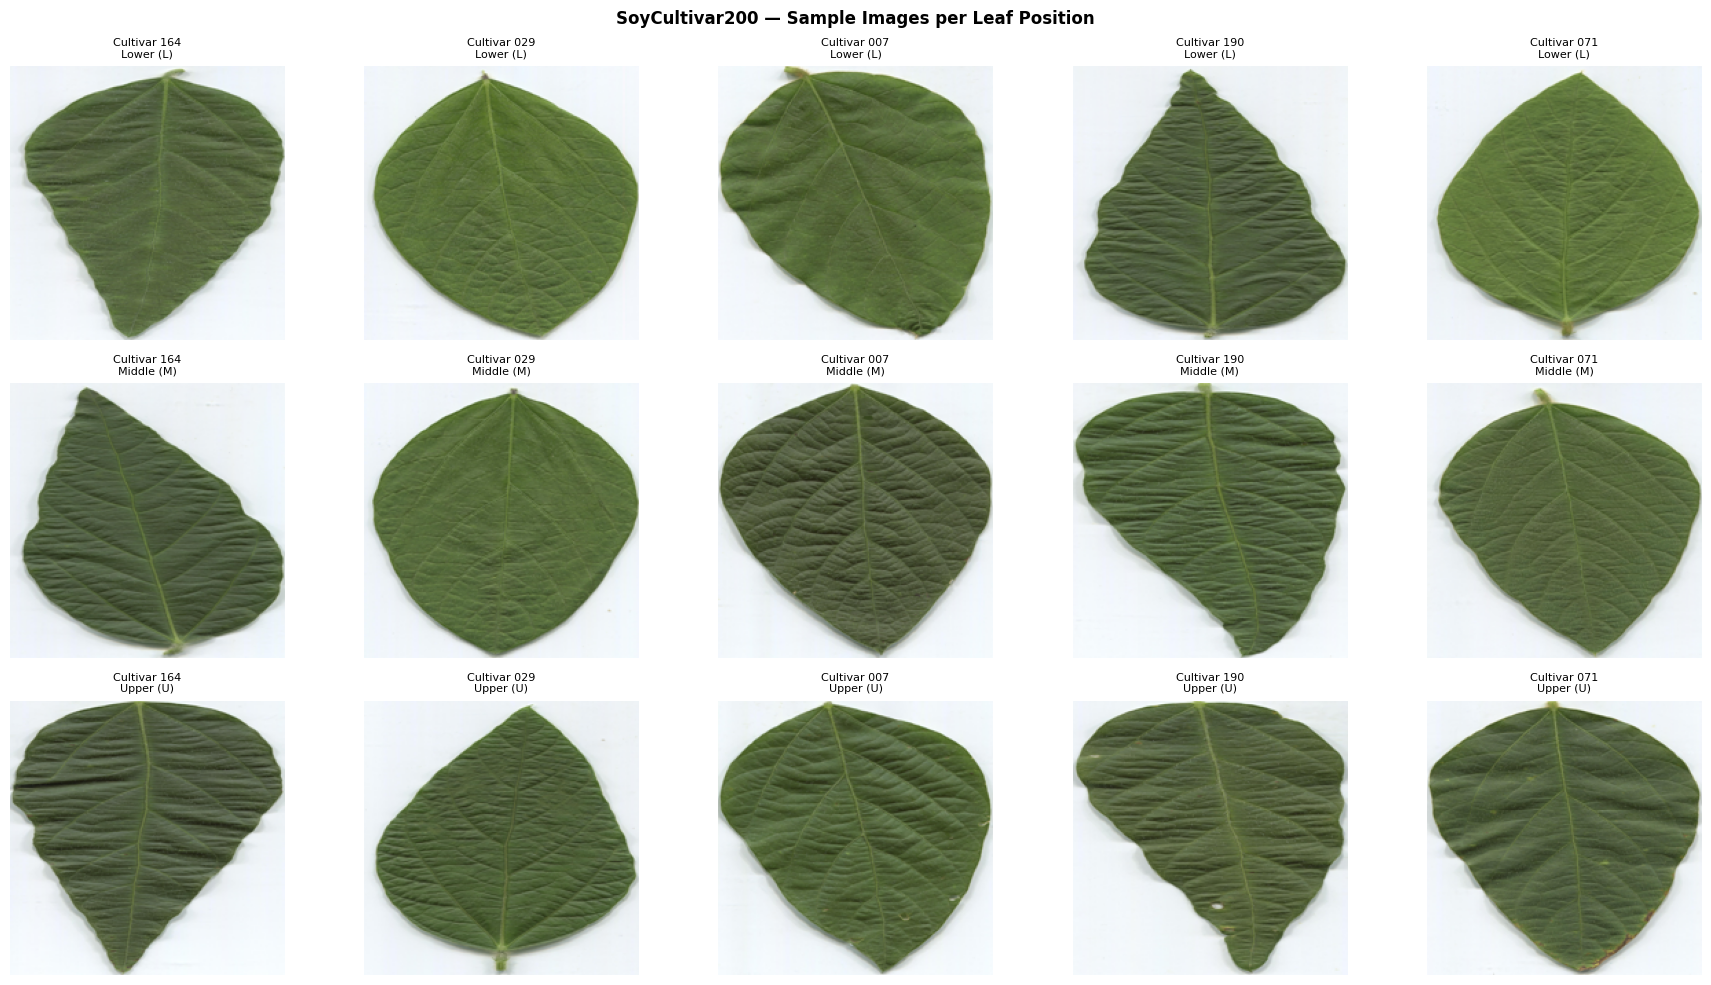

Total Lower images : 2000 (200 classes x 10)
Total Middle images: 2000
Total Upper images : 2000
Grand total        : 6000 images


In [7]:
random.seed(SEED)
sample_cultivars = random.sample(TARGET_CLASSES, 5)
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
for col, cls in enumerate(sample_cultivars):
    for row, (split_dir, label) in enumerate([
        (LOWER_DIR,  'Lower (L)'),
        (MIDDLE_DIR, 'Middle (M)'),
        (UPPER_DIR,  'Upper (U)'),
    ]):
        imgs = get_images(os.path.join(split_dir, cls))
        ax   = axes[row, col]
        if imgs:
            img = Image.open(random.choice(imgs)).convert('RGB').resize((200,200))
            ax.imshow(img)
        ax.set_title('Cultivar '+cls+chr(10)+label, fontsize=8)
        ax.axis('off')
        for sp in ax.spines.values():
            color = '#5B7FDE' if row==0 else '#52B788' if row==1 else '#E8845A'
            sp.set_edgecolor(color); sp.set_linewidth(2)
fig.suptitle('SoyCultivar200 — Sample Images per Leaf Position', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'eda_samples.png'),dpi=120,bbox_inches='tight')
plt.show()

total = sum(len(get_images(os.path.join(LOWER_DIR,c))) for c in TARGET_CLASSES
            if os.path.isdir(os.path.join(LOWER_DIR,c)))
print('Total Lower images : '+str(total)+' ('+str(NUM_CLASSES)+' classes x 10)')
print('Total Middle images: '+str(total))
print('Total Upper images : '+str(total))
print('Grand total        : '+str(total*3)+' images')


## Data Pipelines — one per leaf position

No augmentation — baseline experiment.  
Each leaf position gets its own train/val/test split using the same `SEED`.


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

def load_img(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32)/255.0, label

def make_ds(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training: ds = ds.shuffle(min(len(paths),5000), seed=SEED)
    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

def build_split(split_dir, label=''):
    paths, labels = [], []
    for cls in TARGET_CLASSES:
        imgs = get_images(os.path.join(split_dir, cls))
        if not imgs: continue
        paths.extend(imgs)
        labels.extend([CLASS_TO_IDX[cls]]*len(imgs))
    paths  = np.array(paths)
    labels = np.array(labels, dtype=np.int32)
    X_tr,X_tmp,y_tr,y_tmp = train_test_split(
        paths,labels,test_size=0.30,random_state=SEED,stratify=labels)
    X_val,X_te,y_val,y_te = train_test_split(
        X_tmp,y_tmp,test_size=0.50,random_state=SEED,stratify=y_tmp)
    print(label+' | Train '+str(len(X_tr))+' Val '+str(len(X_val))+' Test '+str(len(X_te)))
    tr_ds  = make_ds(X_tr, y_tr, training=True)
    val_ds = make_ds(X_val, y_val)
    te_ds  = make_ds(X_te, y_te)
    return tr_ds, val_ds, te_ds, X_te, y_te

lower_train_ds,  lower_val_ds,  lower_test_ds,  X_te_L, y_te_L = build_split(LOWER_DIR,  'Lower ')
middle_train_ds, middle_val_ds, middle_test_ds, X_te_M, y_te_M = build_split(MIDDLE_DIR, 'Middle')
upper_train_ds,  upper_val_ds,  upper_test_ds,  X_te_U, y_te_U = build_split(UPPER_DIR,  'Upper ')

all_labels_lower = np.array([CLASS_TO_IDX[c] for c in TARGET_CLASSES
                              for _ in get_images(os.path.join(LOWER_DIR,c))])
present = np.unique(all_labels_lower)
cw_vals = compute_class_weight('balanced',classes=present,y=all_labels_lower)
class_weights = {i:1.0 for i in range(NUM_CLASSES)}
for idx,w in zip(present,cw_vals): class_weights[idx]=w
print('Class weights computed (all should be ~1.0 since dataset is balanced).')

class CosineWarmupScheduler(LearningRateScheduler):
    def __init__(self,initial_lr,total_epochs,warmup_epochs=5):
        self.initial_lr=initial_lr; self.total_epochs=total_epochs; self.warmup=warmup_epochs
        super().__init__(self._sched,verbose=0)
    def _sched(self,epoch,lr):
        if epoch<self.warmup: return self.initial_lr*(epoch+1)/self.warmup
        t=epoch-self.warmup; T=self.total_epochs-self.warmup
        return 0.5*self.initial_lr*(1+math.cos(math.pi*t/T))
    def get_config(self):
        cfg=super().get_config()
        cfg.update({'initial_lr':self.initial_lr,'total_epochs':self.total_epochs,'warmup_epochs':self.warmup})
        return cfg
print('Scheduler ready.')


Lower  | Train 1400 Val 300 Test 300
Middle | Train 1400 Val 300 Test 300
Upper  | Train 1400 Val 300 Test 300
Class weights computed (all should be ~1.0 since dataset is balanced).
Scheduler ready.


## Architecture — Proposed (Inception_cell + SkipConnection)

Same custom architecture used for all three sub-models.
```
Input(256x256x3)
-> Inception_cell(16) [3x3+5x5+7x7 Add] -> BN -> MaxPool  -> (128x128x16)
-> Inception_cell(32) [3x3+5x5+7x7 Add] -> BN -> MaxPool  -> ( 64x 64x32)
-> SkipConnection(64) [Conv7x7->BN->Concat]   -> MaxPool  -> ( 32x 32x96)
-> SkipConnection(128)[Conv7x7->BN->Concat]   -> MaxPool  -> ( 16x 16x224)
-> GAP(224) -> Dense(512) -> Drop(0.5) -> Dense(256) -> Drop(0.3) -> Softmax(200)
```


In [9]:
class Inception_cell(Layer):
    """3 parallel convolutions (3x3, 5x5, 7x7) fused by element-wise Add."""
    def __init__(self,num_filters,activation='relu',padding='same',**kwargs):
        super().__init__(**kwargs)
        self.num_filters=num_filters; self.activation=activation; self.padding=padding
        self.conv3=Conv2D(num_filters,(3,3),activation=activation,padding=padding)
        self.conv5=Conv2D(num_filters,(5,5),activation=activation,padding=padding)
        self.conv7=Conv2D(num_filters,(7,7),activation=activation,padding=padding)
    def call(self,x,training=False):
        return Add()([self.conv3(x),self.conv5(x),self.conv7(x)])
    def get_config(self):
        cfg=super().get_config()
        cfg.update({'num_filters':self.num_filters,'activation':self.activation,'padding':self.padding})
        return cfg

class SkipConnection(Layer):
    """Conv7x7 -> BN -> Concatenate(input) — DenseNet-style skip."""
    def __init__(self,num_filters,kernel_size=7,activation='relu',padding='same',**kwargs):
        super().__init__(**kwargs)
        self.num_filters=num_filters; self.kernel_size=kernel_size
        self.conv=Conv2D(num_filters,(7,7),activation=activation,padding=padding)
        self.bn=BatchNormalization()
    def call(self,x,training=False):
        out=self.conv(x); out=self.bn(out,training=training)
        return Concatenate(axis=-1)([out,x])
    def get_config(self):
        cfg=super().get_config()
        cfg.update({'num_filters':self.num_filters,'kernel_size':self.kernel_size})
        return cfg

def build_sub_model(model_name):
    """Builds one Proposed1 sub-model for one leaf position."""
    inp = Input(shape=IMG_SHAPE, name=model_name+'_input')
    x   = Inception_cell(16, name=model_name+'_inc1')(inp)
    x   = BatchNormalization()(x); x = MaxPooling2D((2,2))(x)
    x   = Inception_cell(32, name=model_name+'_inc2')(x)
    x   = BatchNormalization()(x); x = MaxPooling2D((2,2))(x)
    x   = SkipConnection(64,  name=model_name+'_skip1')(x); x = MaxPooling2D((2,2))(x)
    x   = SkipConnection(128, name=model_name+'_skip2')(x); x = MaxPooling2D((2,2))(x)
    x   = GlobalAveragePooling2D(name=model_name+'_gap')(x)
    x   = Dense(512,activation='relu')(x); x = Dropout(DROPOUT_RATE)(x)
    x   = Dense(256,activation='relu')(x); x = Dropout(0.3)(x)
    out = Dense(NUM_CLASSES,activation='softmax',name=model_name+'_out')(x)
    return Model(inp,out,name=model_name)

lower_model  = build_sub_model('lower_model')
middle_model = build_sub_model('middle_model')
upper_model  = build_sub_model('upper_model')

lower_model.summary()
print('Each sub-model params: '+str(lower_model.count_params()))


Model: "lower_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lower_model_input (InputLayer)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lower_model_inc1                │ (None, 256, 256, 16)   │         4,032 │
│ (Inception_cell)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lower_model_inc2                │ (None, 128, 128, 32)   │        42,592 │
│ (Inception_cell)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lower_model_skip1               │ (None, 64, 64, 96)     │       100,672 │
│ (SkipConnection)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lower_model_skip2               │ (None, 32, 32, 224)    │       602,752 │
│ (SkipConnection)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lower_model_gap                 │ (None, 224)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lower_model_out (Dense)         │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,048,168 (4.00 MB)

 Trainable params: 1,047,688 (4.00 MB)

 Non-trainable params: 480 (1.88 KB)

Each sub-model params: 1048168


## Training — Lower Leaf Sub-model


In [10]:
ckpt_lower = os.path.join(CKPT_DIR,'lower_best.weights.h5')
lower_model.compile(optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
                    loss='sparse_categorical_crossentropy',metrics=['accuracy'])
callbacks_lower = [
    CosineWarmupScheduler(INITIAL_LR,EPOCHS,warmup_epochs=5),
    ModelCheckpoint(ckpt_lower,monitor='val_accuracy',save_best_only=True,
                    save_weights_only=True,verbose=0),
    EarlyStopping(monitor='val_loss',patience=12,restore_best_weights=True,verbose=1),
]
tracemalloc.start(); t0=time.time()
history_lower = lower_model.fit(lower_train_ds,epochs=EPOCHS,
                                validation_data=lower_val_ds,
                                class_weight=class_weights,
                                callbacks=callbacks_lower,verbose=1)
train_time_lower = time.time()-t0
_,pk_lower=tracemalloc.get_traced_memory(); tracemalloc.stop()
lower_model.save(os.path.join(BASE_DIR,'lower_model.h5'))
print('Lower model done: '+str(round(train_time_lower/60,1))+' min')
print('Best val_acc: '+str(round(max(history_lower.history['val_accuracy']),4)))


Epoch 1/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.0071 - loss: 5.3396 - val_accuracy: 0.0067 - val_loss: 5.6129 - learning_rate: 2.0000e-04
Epoch 2/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 610ms/step - accuracy: 0.0107 - loss: 5.2530 - val_accuracy: 0.0100 - val_loss: 5.4235 - learning_rate: 4.0000e-04
Epoch 3/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 583ms/step - accuracy: 0.0136 - loss: 5.1011 - val_accuracy: 0.0033 - val_loss: 6.2873 - learning_rate: 6.0000e-04
Epoch 4/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 585ms/step - accuracy: 0.0200 - loss: 4.9069 - val_accuracy: 0.0033 - val_loss: 8.0133 - learning_rate: 8.0000e-04
Epoch 5/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 583ms/step - accuracy: 0.0257 - loss: 4.6865 - val_accuracy: 0.0033 - val_loss: 10.8649 - learning_rate: 0.0010
Epoch 6/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 585ms/step - accuracy: 0.0350 - loss: 4.5190 - val_accuracy: 0.0033 - val_loss: 11.5228 - learning_rate: 0.0010
Epoch 7/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 583ms/step - accuracy: 0.

Lower model done: 7.9 min
Best val_acc: 0.0367


## Training — Middle Leaf Sub-model


In [11]:
ckpt_middle = os.path.join(CKPT_DIR,'middle_best.weights.h5')
middle_model.compile(optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
                     loss='sparse_categorical_crossentropy',metrics=['accuracy'])
callbacks_middle = [
    CosineWarmupScheduler(INITIAL_LR,EPOCHS,warmup_epochs=5),
    ModelCheckpoint(ckpt_middle,monitor='val_accuracy',save_best_only=True,
                    save_weights_only=True,verbose=0),
    EarlyStopping(monitor='val_loss',patience=12,restore_best_weights=True,verbose=1),
]
tracemalloc.start(); t0=time.time()
history_middle = middle_model.fit(middle_train_ds,epochs=EPOCHS,
                                  validation_data=middle_val_ds,
                                  class_weight=class_weights,
                                  callbacks=callbacks_middle,verbose=1)
train_time_middle = time.time()-t0
_,pk_middle=tracemalloc.get_traced_memory(); tracemalloc.stop()
middle_model.save(os.path.join(BASE_DIR,'middle_model.h5'))
print('Middle model done: '+str(round(train_time_middle/60,1))+' min')
print('Best val_acc: '+str(round(max(history_middle.history['val_accuracy']),4)))


Epoch 1/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 56s 834ms/step - accuracy: 0.0021 - loss: 5.3677 - val_accuracy: 0.0067 - val_loss: 5.3790 - learning_rate: 2.0000e-04
Epoch 2/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 25s 560ms/step - accuracy: 0.0079 - loss: 5.2844 - val_accuracy: 0.0033 - val_loss: 5.3729 - learning_rate: 4.0000e-04
Epoch 3/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 519ms/step - accuracy: 0.0164 - loss: 5.1816 - val_accuracy: 0.0033 - val_loss: 6.5588 - learning_rate: 6.0000e-04
Epoch 4/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 517ms/step - accuracy: 0.0057 - loss: 5.0224 - val_accuracy: 0.0067 - val_loss: 7.3230 - learning_rate: 8.0000e-04
Epoch 5/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 512ms/step - accuracy: 0.0264 - loss: 4.7826 - val_accuracy: 0.0067 - val_loss: 8.8570 - learning_rate: 0.0010
Epoch 6/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 25s 560ms/step - accuracy: 0.0293 - loss: 4.5377 - val_accuracy: 0.0100 - val_loss: 6.4744 - learning_rate: 0.0010
Epoch 7/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 40s 528ms/step - accuracy: 0

Middle model done: 7.8 min
Best val_acc: 0.0167


## Training — Upper Leaf Sub-model


In [12]:
ckpt_upper = os.path.join(CKPT_DIR,'upper_best.weights.h5')
upper_model.compile(optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
                    loss='sparse_categorical_crossentropy',metrics=['accuracy'])
callbacks_upper = [
    CosineWarmupScheduler(INITIAL_LR,EPOCHS,warmup_epochs=5),
    ModelCheckpoint(ckpt_upper,monitor='val_accuracy',save_best_only=True,
                    save_weights_only=True,verbose=0),
    EarlyStopping(monitor='val_loss',patience=12,restore_best_weights=True,verbose=1),
]
tracemalloc.start(); t0=time.time()
history_upper = upper_model.fit(upper_train_ds,epochs=EPOCHS,
                                validation_data=upper_val_ds,
                                class_weight=class_weights,
                                callbacks=callbacks_upper,verbose=1)
train_time_upper = time.time()-t0
_,pk_upper=tracemalloc.get_traced_memory(); tracemalloc.stop()
upper_model.save(os.path.join(BASE_DIR,'upper_model.h5'))
print('Upper model done: '+str(round(train_time_upper/60,1))+' min')
print('Best val_acc: '+str(round(max(history_upper.history['val_accuracy']),4)))


Epoch 1/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 50s 684ms/step - accuracy: 0.0064 - loss: 5.3444 - val_accuracy: 0.0067 - val_loss: 5.5717 - learning_rate: 2.0000e-04
Epoch 2/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 440ms/step - accuracy: 0.0064 - loss: 5.2582 - val_accuracy: 0.0033 - val_loss: 5.7056 - learning_rate: 4.0000e-04
Epoch 3/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 507ms/step - accuracy: 0.0143 - loss: 5.1532 - val_accuracy: 0.0033 - val_loss: 9.7715 - learning_rate: 6.0000e-04
Epoch 4/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 470ms/step - accuracy: 0.0221 - loss: 4.9749 - val_accuracy: 0.0033 - val_loss: 12.4094 - learning_rate: 8.0000e-04
Epoch 5/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 491ms/step - accuracy: 0.0221 - loss: 4.7582 - val_accuracy: 0.0100 - val_loss: 9.7647 - learning_rate: 0.0010
Epoch 6/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 510ms/step - accuracy: 0.0364 - loss: 4.4668 - val_accuracy: 0.0067 - val_loss: 7.3689 - learning_rate: 0.0010
Epoch 7/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 461ms/step - accuracy: 

Upper model done: 10.7 min
Best val_acc: 0.07


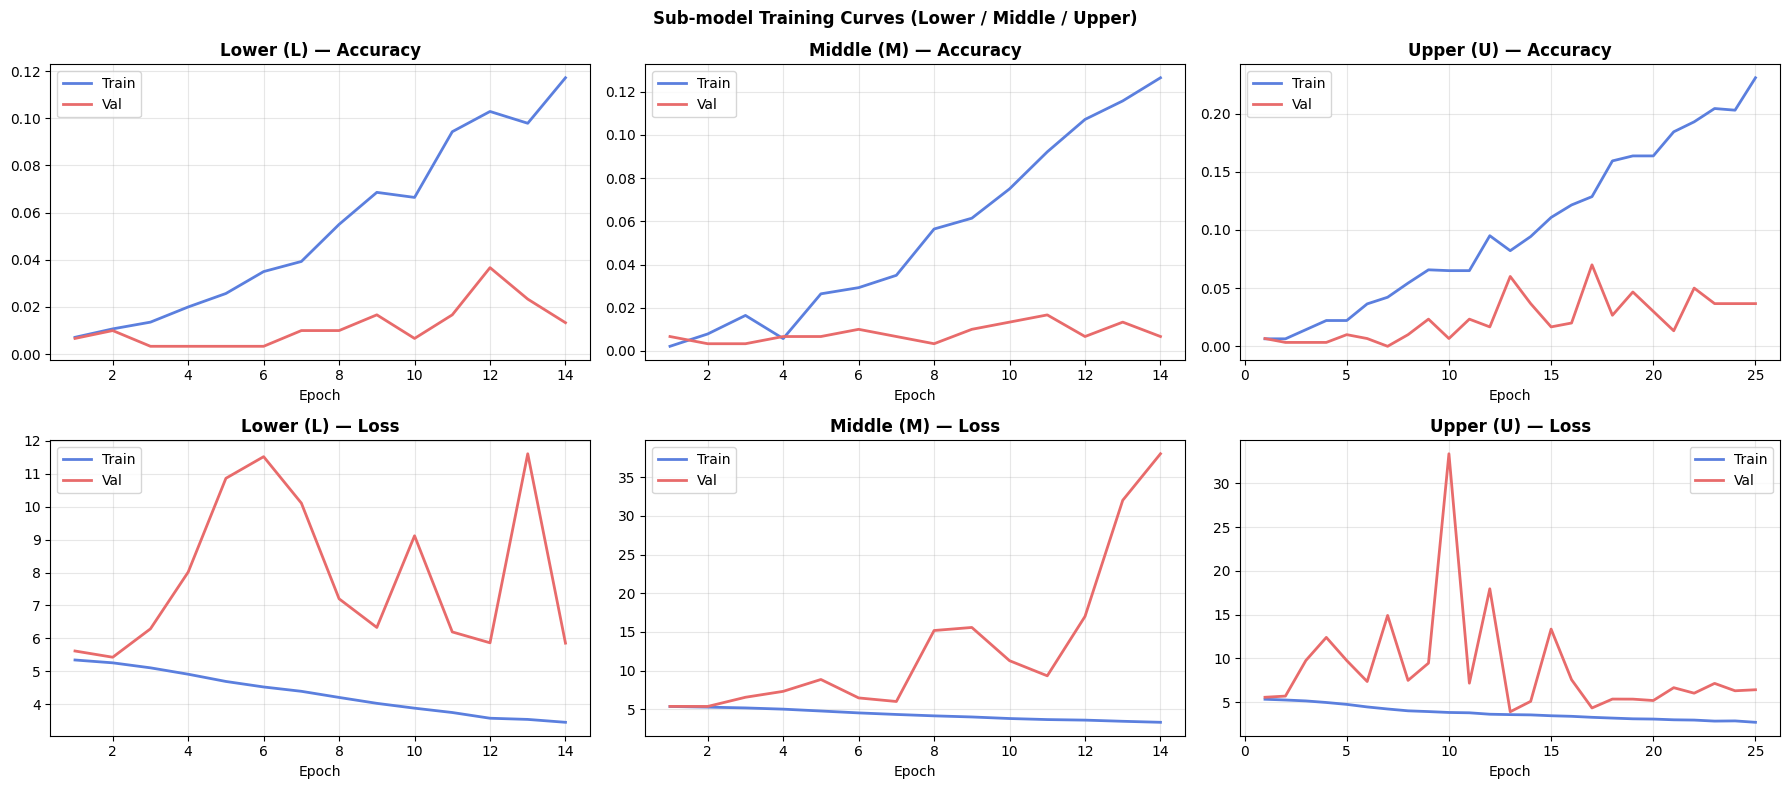

Sub-model curves saved.


In [13]:
fig, axes = plt.subplots(2,3,figsize=(18,8))
for col,(hist,label) in enumerate([
    (history_lower.history,  'Lower (L)'),
    (history_middle.history, 'Middle (M)'),
    (history_upper.history,  'Upper (U)'),
]):
    ep = range(1,len(hist['loss'])+1)
    axes[0,col].plot(ep,hist['accuracy'],label='Train',color='#5B7FDE',lw=2)
    axes[0,col].plot(ep,hist['val_accuracy'],label='Val',color='#E86B6B',lw=2)
    axes[0,col].set_title(label+' — Accuracy',fontweight='bold')
    axes[0,col].legend(); axes[0,col].grid(alpha=0.3)
    axes[0,col].set_xlabel('Epoch')
    axes[1,col].plot(ep,hist['loss'],label='Train',color='#5B7FDE',lw=2)
    axes[1,col].plot(ep,hist['val_loss'],label='Val',color='#E86B6B',lw=2)
    axes[1,col].set_title(label+' — Loss',fontweight='bold')
    axes[1,col].legend(); axes[1,col].grid(alpha=0.3)
    axes[1,col].set_xlabel('Epoch')
plt.suptitle('Sub-model Training Curves (Lower / Middle / Upper)',fontweight='bold',fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR,'submodel_training_curves.png'),dpi=120,bbox_inches='tight')
plt.show()

for hist,name in [(history_lower,'lower'),(history_middle,'middle'),(history_upper,'upper')]:
    pd.DataFrame(hist.history).assign(epoch=range(1,len(hist.history['loss'])+1),
        submodel=name).to_csv(os.path.join(LOG_DIR,name+'_history.csv'),index=False)
print('Sub-model curves saved.')


## Final Ensemble Model

The three sub-models are frozen. Their softmax outputs (200,) are concatenated -> (600,).  
A small dense head learns how to combine the three leaf-view predictions.
```
Lower predictions  (200,) -+
Middle predictions (200,) -+-> Concat(600,) -> Dense(512) -> Dense(200) -> Softmax(200)
Upper predictions  (200,) -+
```


In [14]:
if os.path.exists(ckpt_lower):  lower_model.load_weights(ckpt_lower)
if os.path.exists(ckpt_middle): middle_model.load_weights(ckpt_middle)
if os.path.exists(ckpt_upper):  upper_model.load_weights(ckpt_upper)

lower_model.trainable  = False
middle_model.trainable = False
upper_model.trainable  = False

inp_L = Input(shape=IMG_SHAPE, name='input_lower')
inp_M = Input(shape=IMG_SHAPE, name='input_middle')
inp_U = Input(shape=IMG_SHAPE, name='input_upper')

pred_L = lower_model(inp_L,   training=False)
pred_M = middle_model(inp_M,  training=False)
pred_U = upper_model(inp_U,   training=False)

fused = Concatenate(axis=-1)([pred_L, pred_M, pred_U])

x   = Dense(512, activation='relu')(fused)
x   = Dropout(0.4)(x)
x   = Dense(256, activation='relu')(x)
x   = Dropout(0.3)(x)
out = Dense(NUM_CLASSES, activation='softmax', name='ensemble_out')(x)

final_model = Model(inputs=[inp_L,inp_M,inp_U], outputs=out, name='FinalEnsemble')
final_model.summary()
print('Final model total params: '+str(final_model.count_params()))
print('Trainable params (head only): '+
      str(sum(int(tf.size(w)) for w in final_model.trainable_weights)))


Model: "FinalEnsemble"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_lower         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_middle        │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_upper         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lower_model         │ (None, 200)       │  1,048,168 │ input_lower[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ middle_model        │ (None, 200)       │  1,048,168 │ input_middle[0][… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ upper_model         │ (None, 200)       │  1,048,168 │ input_upper[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_30      │ (None, 600)       │          0 │ lower_model[0][0… │
│ (Concatenate)       │                   │            │ middle_model[0][… │
│                     │                   │            │ upper_model[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 512)       │    307,712 │ concatenate_30[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 512)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │    131,328 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 256)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ensemble_out        │ (None, 200)       │     51,400 │ dropout_7[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,634,944 (13.87 MB)

 Trainable params: 490,440 (1.87 MB)

 Non-trainable params: 3,144,504 (12.00 MB)

Final model total params: 3634944
Trainable params (head only): 490440


## Ensemble Dataset — Triplet batches (L, M, U) per sample

For the final model, every batch must contain corresponding L/M/U images for the same cultivar instances.


In [15]:
def build_triplet_paths():
    paths_L, paths_M, paths_U, labels_all = [], [], [], []

    for cls in TARGET_CLASSES:
        cls_idx = CLASS_TO_IDX[cls]
        l_imgs = sorted(get_images(os.path.join(LOWER_DIR,  cls)))
        m_imgs = sorted(get_images(os.path.join(MIDDLE_DIR, cls)))
        u_imgs = sorted(get_images(os.path.join(UPPER_DIR,  cls)))
        n = min(len(l_imgs), len(m_imgs), len(u_imgs))
        paths_L.extend(l_imgs[:n])
        paths_M.extend(m_imgs[:n])
        paths_U.extend(u_imgs[:n])
        labels_all.extend([cls_idx]*n)

    return (np.array(paths_L), np.array(paths_M),
            np.array(paths_U), np.array(labels_all,dtype=np.int32))

pL, pM, pU, all_labels_triplet = build_triplet_paths()
print('Triplet dataset: '+str(len(pL))+' samples')

idx = np.arange(len(pL))
idx_tr,idx_tmp = train_test_split(idx,test_size=0.30,random_state=SEED,stratify=all_labels_triplet)
idx_val,idx_te = train_test_split(idx_tmp,test_size=0.50,random_state=SEED,
                                   stratify=all_labels_triplet[idx_tmp])

def make_triplet_ds(il, im, iu, labels, training=False):
    def load_triplet(pl, pm, pu, lbl):
        def _load(p):
            raw=tf.io.read_file(p)
            img=tf.image.decode_image(raw,channels=3,expand_animations=False)
            img=tf.image.resize(img,IMG_SIZE)
            return tf.cast(img,tf.float32)/255.0
        return _load(pl), _load(pm), _load(pu), lbl
    ds = tf.data.Dataset.from_tensor_slices((il, im, iu, labels))
    if training: ds = ds.shuffle(min(len(il),5000),seed=SEED)
    ds = ds.map(load_triplet, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    ds = ds.map(lambda l,m,u,lbl: ((l,m,u), lbl))
    return ds

final_train_ds = make_triplet_ds(pL[idx_tr], pM[idx_tr], pU[idx_tr],
                                  all_labels_triplet[idx_tr], training=True)
final_val_ds   = make_triplet_ds(pL[idx_val],pM[idx_val],pU[idx_val],
                                  all_labels_triplet[idx_val])
final_test_ds  = make_triplet_ds(pL[idx_te], pM[idx_te], pU[idx_te],
                                  all_labels_triplet[idx_te])
y_te_final     = all_labels_triplet[idx_te]

print('Train: '+str(len(idx_tr))+' | Val: '+str(len(idx_val))+' | Test: '+str(len(idx_te)))


Triplet dataset: 2000 samples
Train: 1400 | Val: 300 | Test: 300


## Training — Final Ensemble Model


In [16]:
ckpt_final = os.path.join(CKPT_DIR,'final_best.weights.h5')
final_model.compile(optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
                    loss='sparse_categorical_crossentropy',metrics=['accuracy'])
callbacks_final = [
    CosineWarmupScheduler(INITIAL_LR, 30, warmup_epochs=3),
    ModelCheckpoint(ckpt_final,monitor='val_accuracy',save_best_only=True,
                    save_weights_only=True,verbose=0),
    EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True,verbose=1),
]
tracemalloc.start(); t0=time.time()
history_final = final_model.fit(final_train_ds, epochs=30,
                                validation_data=final_val_ds,
                                callbacks=callbacks_final, verbose=1)
train_time_final = time.time()-t0
_,pk_final=tracemalloc.get_traced_memory(); tracemalloc.stop()
ram_used_mb = psutil.Process().memory_info().rss/1e6
final_model.save(os.path.join(BASE_DIR,'final_model.h5'))
print('Final model done: '+str(round(train_time_final/60,1))+' min')
print('Best val_acc: '+str(round(max(history_final.history['val_accuracy']),4)))


Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.0086 - loss: 5.2991 - val_accuracy: 0.0233 - val_loss: 5.2892 - learning_rate: 3.3333e-04
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.0150 - loss: 5.2846 - val_accuracy: 0.0467 - val_loss: 5.2575 - learning_rate: 6.6667e-04
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.0321 - loss: 5.2127 - val_accuracy: 0.0667 - val_loss: 5.0085 - learning_rate: 0.0010
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.0393 - loss: 4.7455 - val_accuracy: 0.1100 - val_loss: 4.1618 - learning_rate: 0.0010
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.0614 - loss: 4.1115 - val_accuracy: 0.1800 - val_loss: 3.5473 - learning_rate: 9.9662e-04
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.1129 - loss: 3.6644 - val_accuracy: 0.2667 - val_loss: 3.1385 - learning_rate: 9.8652e-04
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.1329 - loss: 3.398

Final model done: 41.0 min
Best val_acc: 0.59


## Evaluation — Final Ensemble on Test Set

> All metrics below are on the held-out test set (~600 triplets). Never seen during training.


In [17]:
if os.path.exists(ckpt_final): final_model.load_weights(ckpt_final)

y_prob = final_model.predict(final_test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_te_final[:len(y_pred)]

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
rd   = classification_report(y_true,y_pred,labels=list(range(NUM_CLASSES)),
       target_names=TARGET_CLASSES,output_dict=True,zero_division=0)
spec_list=[]
for i in range(NUM_CLASSES):
    tp=np.sum((y_true==i)&(y_pred==i)); fp=np.sum((y_true!=i)&(y_pred==i))
    tn=np.sum((y_true!=i)&(y_pred!=i))
    spec_list.append(tn/(tn+fp) if (tn+fp)>0 else 0)

print('='*55)
print('FINAL ENSEMBLE — TEST SET RESULTS')
print('='*55)
print('Accuracy    : '+str(round(acc,4))+' ('+str(round(acc*100,2))+'%)')
print('Precision   : '+str(round(prec,4)))
print('Recall      : '+str(round(rec,4)))
print('F1-Score    : '+str(round(f1,4)))
print('Specificity : '+str(round(float(np.mean(spec_list)),4)))
print('Params (sub): '+str(lower_model.count_params()))
print('Params (all): '+str(3*lower_model.count_params()+final_model.count_params()))
print('='*55)


10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step 
FINAL ENSEMBLE — TEST SET RESULTS
Accuracy    : 0.5 (50.0%)
Precision   : 0.4502
Recall      : 0.5
F1-Score    : 0.4456
Specificity : 0.9975
Params (sub): 1048168
Params (all): 6779448


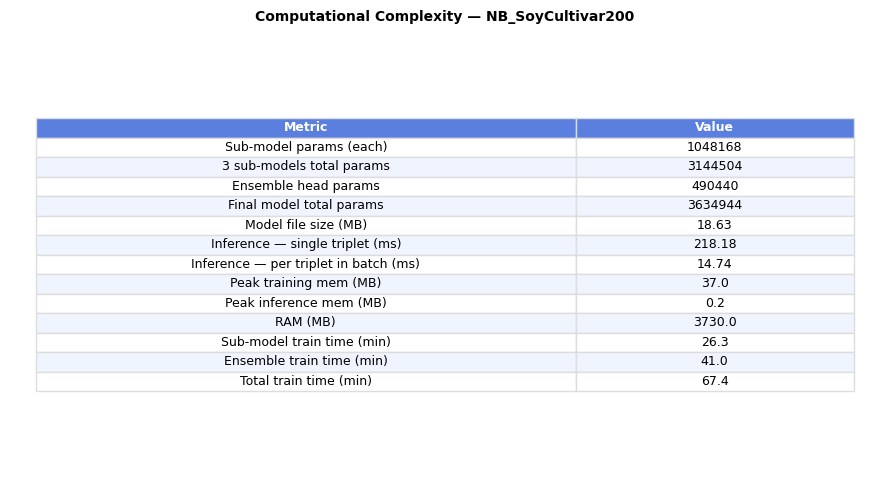

In [18]:
import time as _t
dummy = tf.random.normal([1]+list(IMG_SHAPE))
for _ in range(3): final_model(([dummy,dummy,dummy]), training=False)

times_s = []
for (imgs_l,imgs_m,imgs_u),_ in final_test_ds.unbatch().batch(1).take(30):
    t0=_t.perf_counter()
    final_model(([imgs_l,imgs_m,imgs_u]),training=False)
    times_s.append((_t.perf_counter()-t0)*1000)

times_b = []
for (imgs_l,imgs_m,imgs_u),_ in final_test_ds.take(10):
    t0=_t.perf_counter()
    final_model(([imgs_l,imgs_m,imgs_u]),training=False)
    times_b.append((_t.perf_counter()-t0)*1000)

single_ms   = float(np.mean(times_s))
per_img_ms  = float(np.mean(times_b))/BATCH_SIZE

tracemalloc.start()
for batch in final_test_ds.take(3):
    imgs_batch,_ = batch
    final_model(imgs_batch, training=False)
_,inf_peak = tracemalloc.get_traced_memory(); tracemalloc.stop()

tmp_p='/tmp/_sz.h5'; final_model.save(tmp_p)
sz_mb=os.path.getsize(tmp_p)/1e6; os.remove(tmp_p)

comp_df = pd.DataFrame({'Metric':[
    'Sub-model params (each)','3 sub-models total params',
    'Ensemble head params','Final model total params',
    'Model file size (MB)','Inference — single triplet (ms)',
    'Inference — per triplet in batch (ms)',
    'Peak training mem (MB)','Peak inference mem (MB)','RAM (MB)',
    'Sub-model train time (min)','Ensemble train time (min)',
    'Total train time (min)'],
'Value':[
    str(lower_model.count_params()),
    str(3*lower_model.count_params()),
    str(final_model.count_params()-3*lower_model.count_params()),
    str(final_model.count_params()),
    str(round(sz_mb,2)),
    str(round(single_ms,2)),str(round(per_img_ms,2)),
    str(round(pk_final/1e6,1)),str(round(inf_peak/1e6,1)),str(round(ram_used_mb,0)),
    str(round((train_time_lower+train_time_middle+train_time_upper)/60,1)),
    str(round(train_time_final/60,1)),
    str(round((train_time_lower+train_time_middle+train_time_upper+train_time_final)/60,1))
]})
comp_df.to_csv(os.path.join(LOG_DIR,'complexity.csv'),index=False)

fig,ax=plt.subplots(figsize=(9,5)); ax.axis('off')
tbl=ax.table(cellText=comp_df.values,colLabels=['Metric','Value'],
             cellLoc='center',loc='center',colWidths=[0.62,0.32])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (r,c),cell in tbl.get_celld().items():
    if r==0: cell.set_facecolor('#5B7FDE'); cell.set_text_props(color='white',weight='bold')
    elif r%2==0: cell.set_facecolor('#F0F4FF')
    cell.set_edgecolor('#DDD')
ax.set_title('Computational Complexity — '+NOTEBOOK_ID,fontweight='bold',fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'complexity_table.png'),dpi=130,bbox_inches='tight')
plt.show()


Top 10 confusions:
  True=189 Predicted=183 n=2
  True=134 Predicted=133 n=2
  True=122 Predicted=017 n=2
  True=109 Predicted=087 n=2
  True=064 Predicted=099 n=2
  True=009 Predicted=024 n=2
  True=200 Predicted=196 n=1
  True=200 Predicted=140 n=1
  True=199 Predicted=193 n=1
  True=199 Predicted=150 n=1


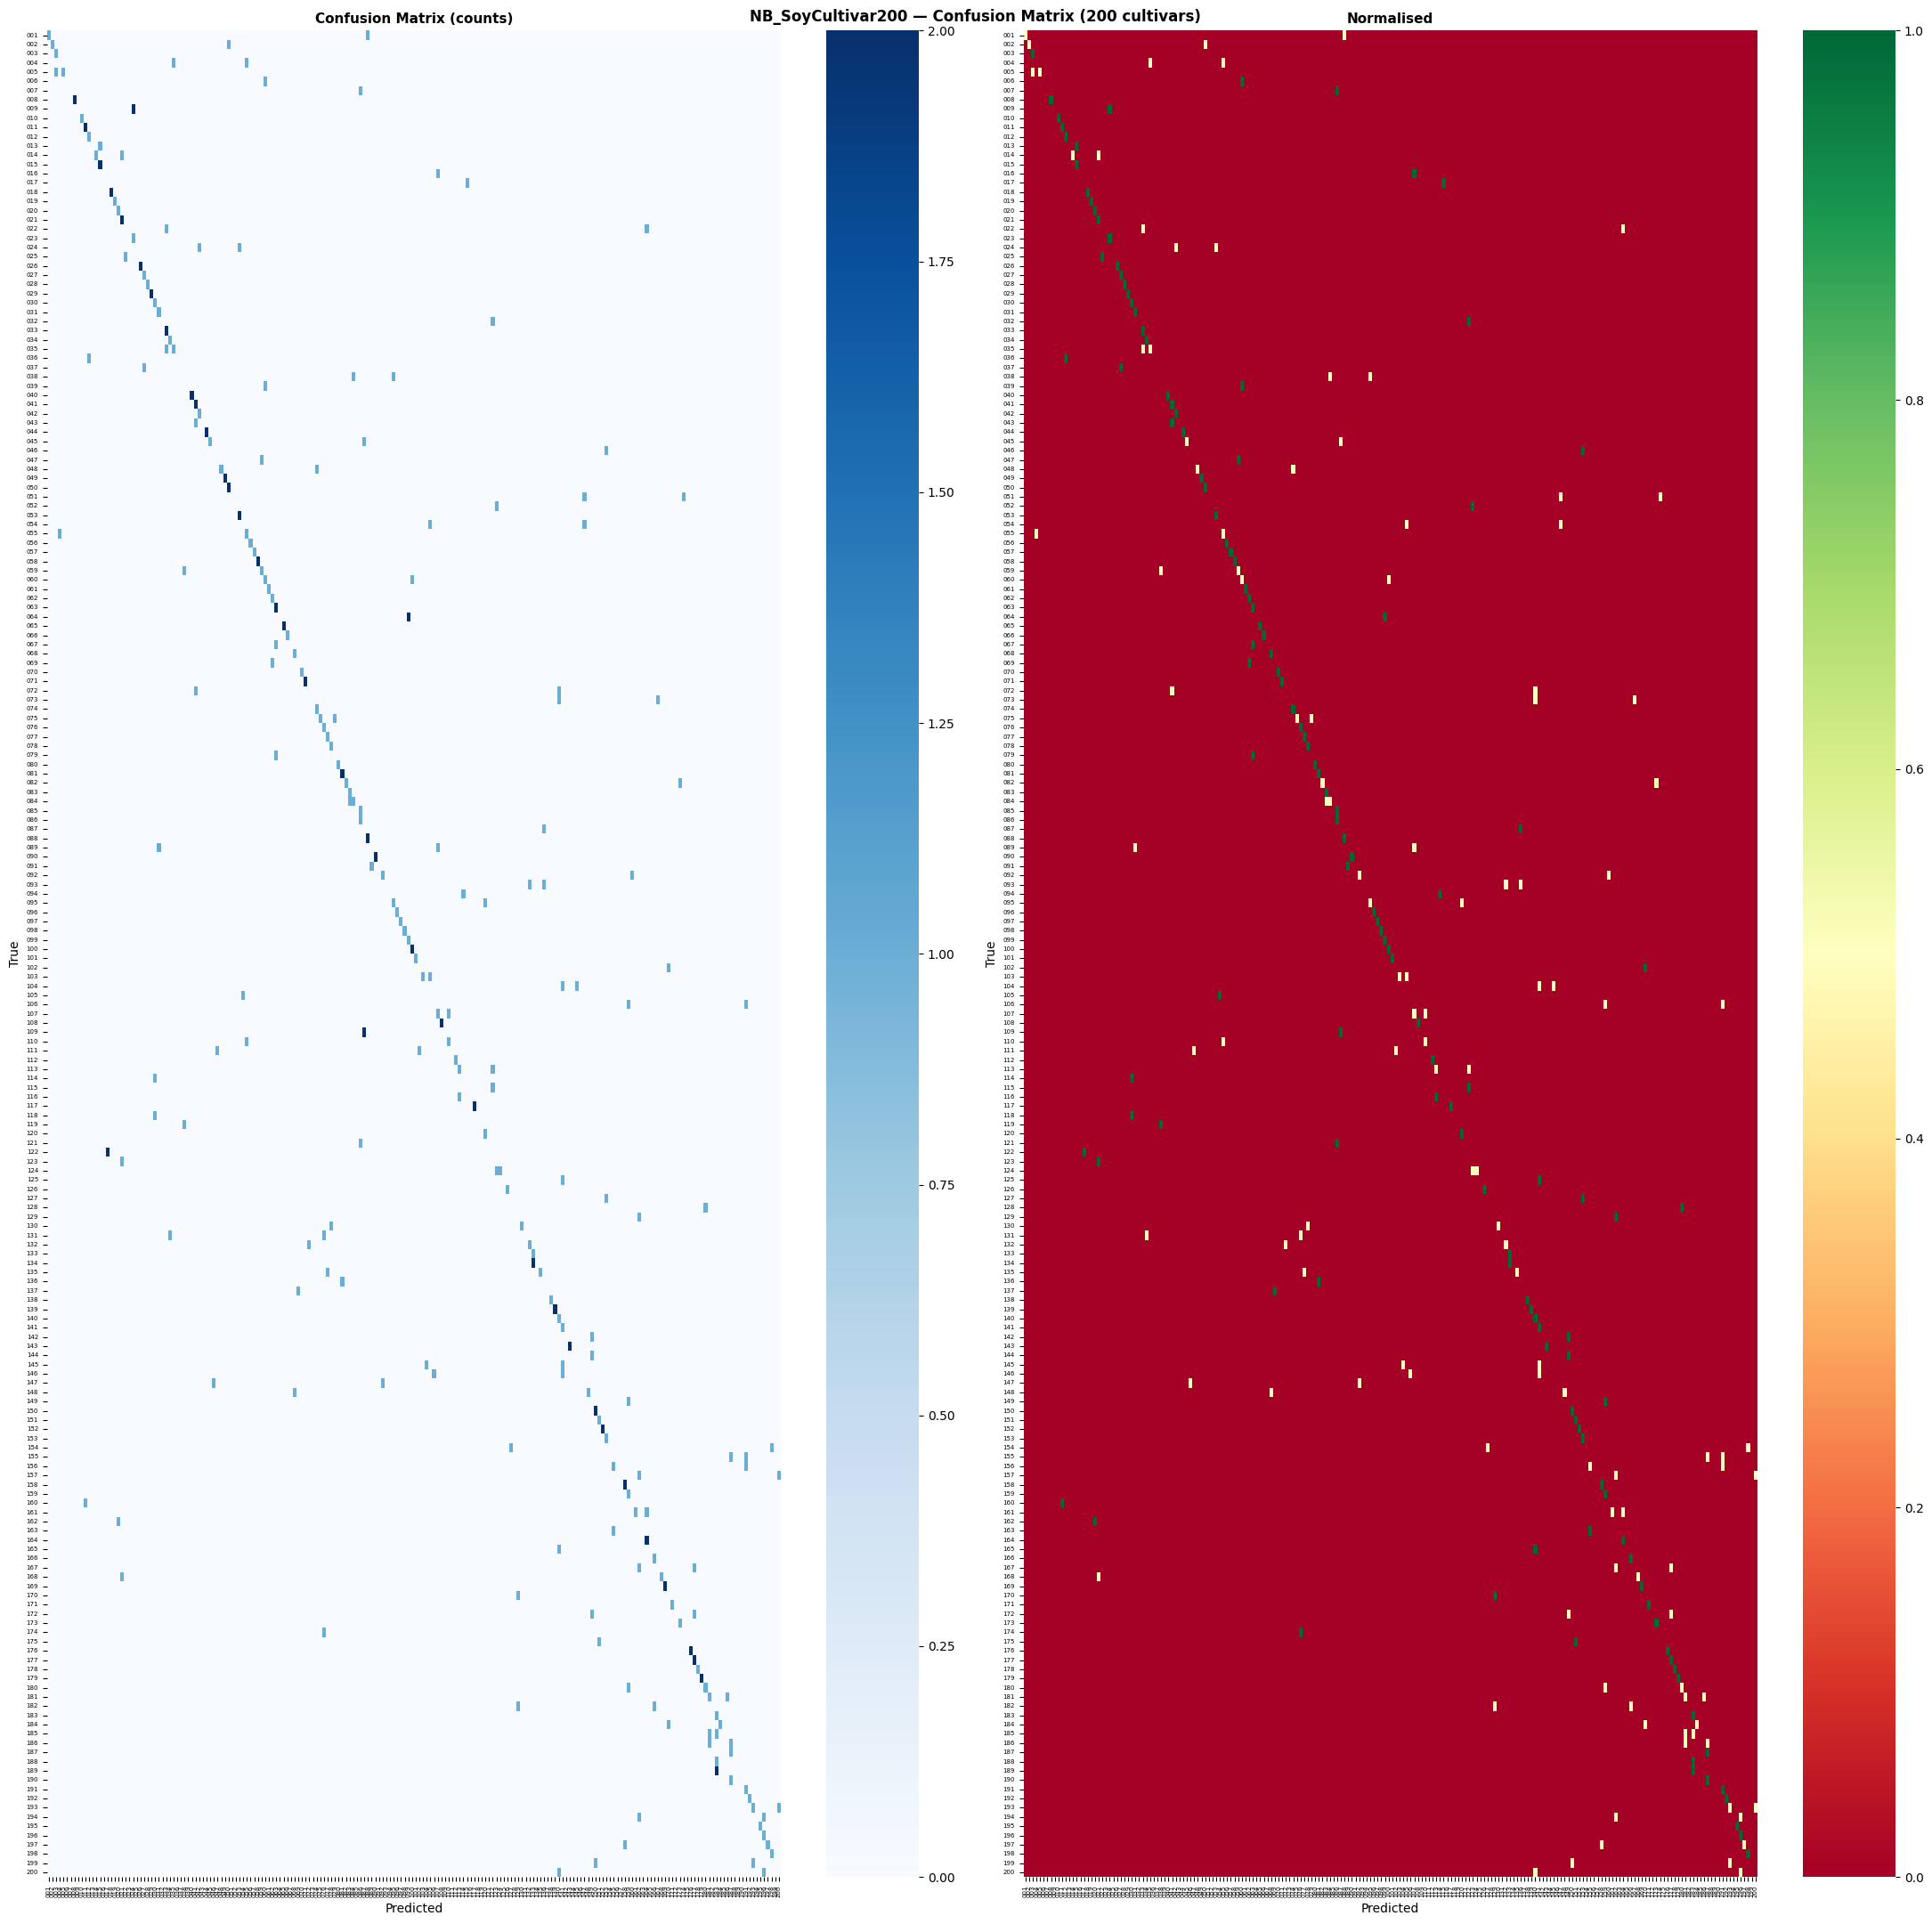

In [19]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float)/np.maximum(cm.sum(axis=1,keepdims=True),1)

fig,axes=plt.subplots(1,2,figsize=(22,22))
for ax,data,fmt,cmap,title in [
    (axes[0],cm,'d','Blues','Confusion Matrix (counts)'),
    (axes[1],cm_norm,'.1f','RdYlGn','Normalised'),
]:
    sns.heatmap(data,ax=ax,cmap=cmap,annot=False,
                xticklabels=TARGET_CLASSES,yticklabels=TARGET_CLASSES,
                linewidths=0.0,linecolor='white',
                **({'vmin':0,'vmax':1} if fmt=='.1f' else {}))
    ax.set_title(title,fontweight='bold',fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x',rotation=90,labelsize=5)
    ax.tick_params(axis='y',rotation=0,labelsize=5)

top_conf=sorted([(cm[i,j],TARGET_CLASSES[i],TARGET_CLASSES[j])
                  for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i!=j],reverse=True)[:10]
print('Top 10 confusions:')
for cnt,t,p in top_conf:
    print('  True='+t+' Predicted='+p+' n='+str(cnt))

plt.suptitle(NOTEBOOK_ID+' — Confusion Matrix (200 cultivars)',fontweight='bold',fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'confusion_matrix.png'),dpi=130,bbox_inches='tight')
plt.show()


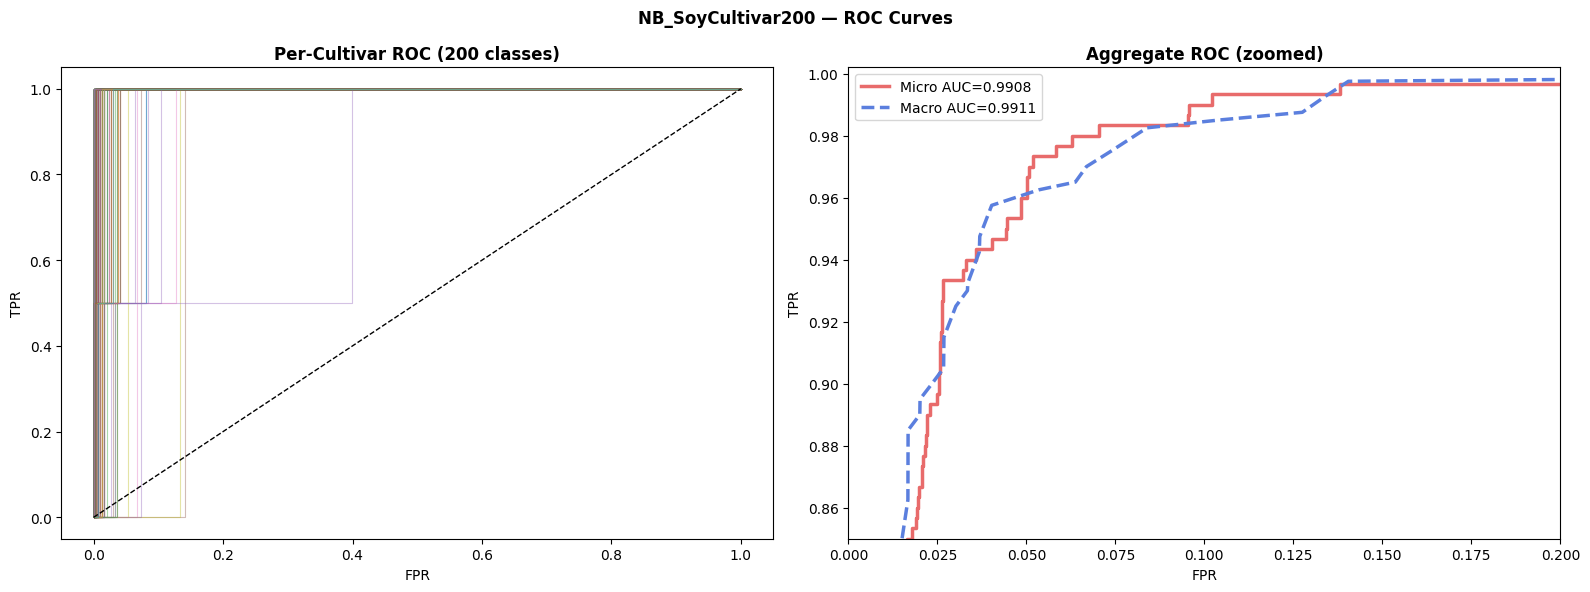

Micro AUC=0.9908  Macro AUC=0.9911


In [20]:
y_bin=label_binarize(y_true,classes=list(range(NUM_CLASSES)))
fpr_d,tpr_d,roc_auc_d,pr_ap={},{},{},{}
for i in range(NUM_CLASSES):
    fpr_d[i],tpr_d[i],_=roc_curve(y_bin[:,i],y_prob[:,i])
    roc_auc_d[i]=auc(fpr_d[i],tpr_d[i])
    pr_ap[i]=average_precision_score(y_bin[:,i],y_prob[:,i])

fpr_d['micro'],tpr_d['micro'],_=roc_curve(y_bin.ravel(),y_prob.ravel())
roc_auc_d['micro']=auc(fpr_d['micro'],tpr_d['micro'])
all_fpr=np.unique(np.concatenate([fpr_d[i] for i in range(NUM_CLASSES)]))
mean_tpr=np.zeros_like(all_fpr)
for i in range(NUM_CLASSES): mean_tpr+=np.interp(all_fpr,fpr_d[i],tpr_d[i])
mean_tpr/=NUM_CLASSES; roc_auc_d['macro']=auc(all_fpr,mean_tpr)

fig,axes=plt.subplots(1,2,figsize=(16,6))
for i in range(NUM_CLASSES):
    alpha=0.4; lw=0.8
    axes[0].plot(fpr_d[i],tpr_d[i],lw=lw,alpha=alpha)
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_title('Per-Cultivar ROC (200 classes)',fontweight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')

axes[1].plot(fpr_d['micro'],tpr_d['micro'],'#E86B6B',lw=2.5,
             label='Micro AUC='+str(round(roc_auc_d["micro"],4)))
axes[1].plot(all_fpr,mean_tpr,'#5B7FDE',lw=2.5,ls='--',
             label='Macro AUC='+str(round(roc_auc_d["macro"],4)))
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlim([0,0.2]); axes[1].set_ylim([0.85,1.002])
axes[1].set_title('Aggregate ROC (zoomed)',fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend(fontsize=10)
plt.suptitle(NOTEBOOK_ID+' — ROC Curves',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'roc_curves.png'),dpi=130,bbox_inches='tight')
plt.show()
print('Micro AUC='+str(round(roc_auc_d["micro"],4))+'  Macro AUC='+str(round(roc_auc_d["macro"],4)))


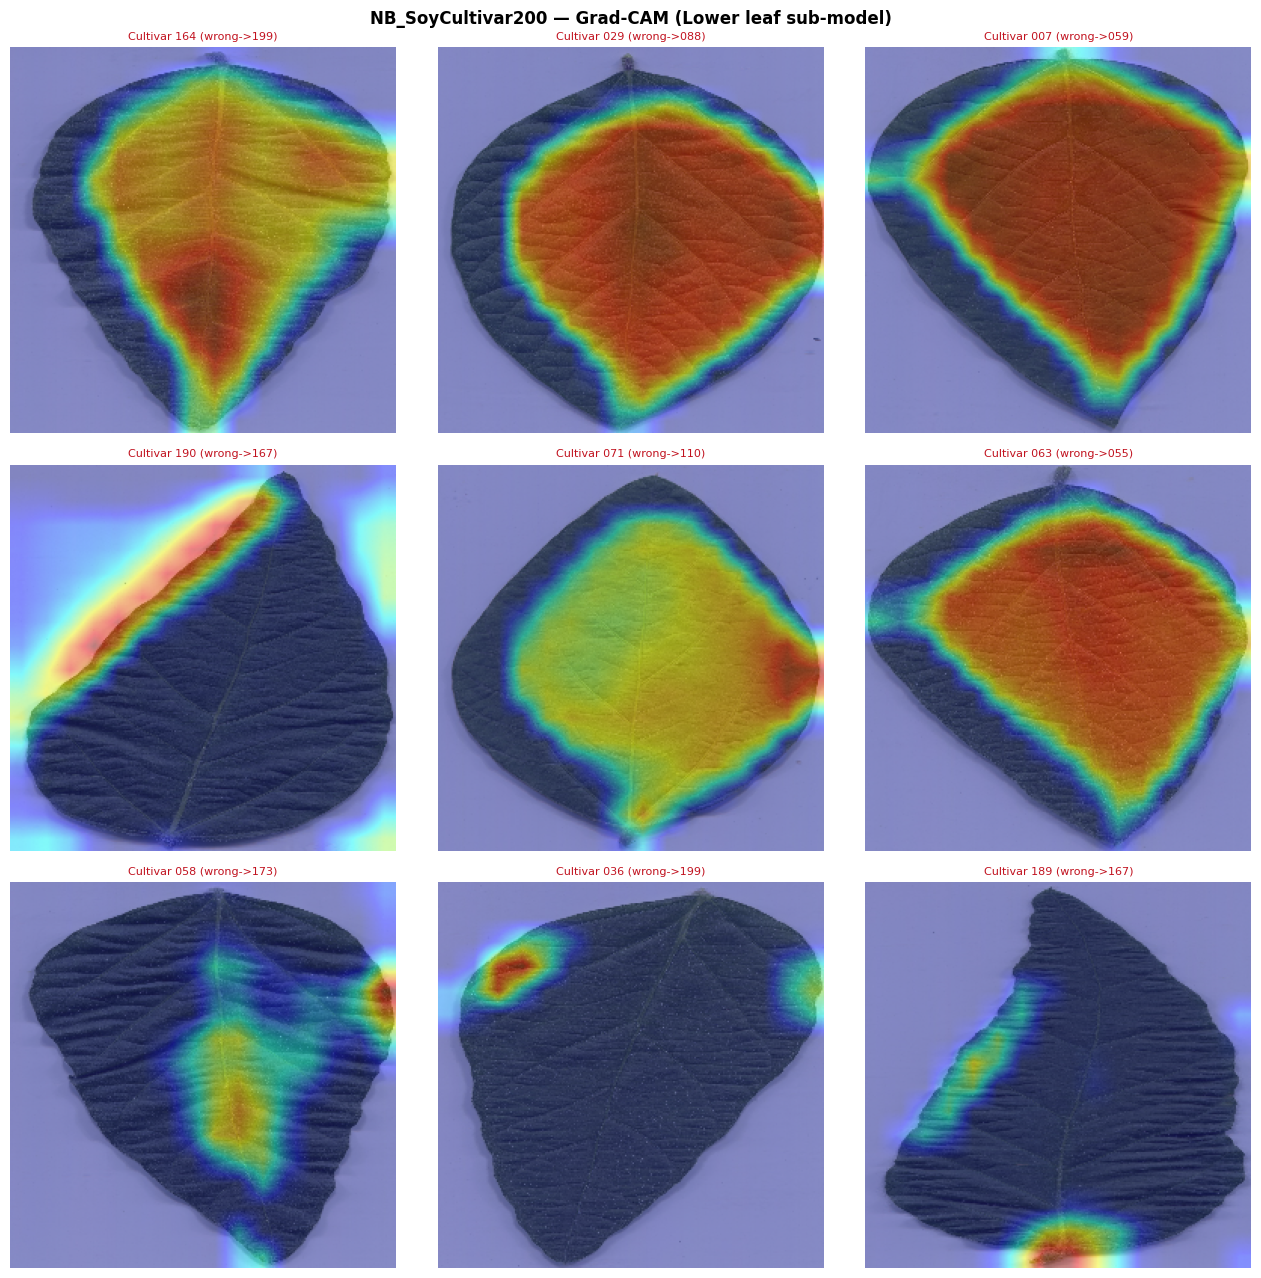

In [21]:
try: import cv2
except: os.system('pip install opencv-python-headless -q'); import cv2

last_conv=next(l.name for l in reversed(lower_model.layers)
               if isinstance(l,(tf.keras.layers.Conv2D,tf.keras.layers.MaxPooling2D)))
grad_model=tf.keras.Model(inputs=lower_model.input,
                           outputs=[lower_model.get_layer(last_conv).output,lower_model.output])

def gradcam(img_t,cls_idx):
    with tf.GradientTape() as tape:
        conv_out,preds=grad_model(img_t[tf.newaxis],training=False)
        score=preds[0][cls_idx]
    grads=tape.gradient(score,conv_out)[0]
    weights=tf.reduce_mean(grads,axis=[0,1])
    cam=tf.reduce_sum(conv_out[0]*weights,axis=-1).numpy()
    cam=np.maximum(cam,0); cam/=(cam.max()+1e-8)
    return cv2.resize(cam,(256,256))

def overlay(img_np,cam):
    hm=cv2.cvtColor(cv2.applyColorMap(np.uint8(255*cam),cv2.COLORMAP_JET),cv2.COLOR_BGR2RGB)/255.0
    return np.clip(0.55*img_np+0.45*hm,0,1)

random.seed(SEED); sample_cls=random.sample(TARGET_CLASSES,9)
fig,axes=plt.subplots(3,3,figsize=(13,13))
for ax,cls in zip(axes.flatten(),sample_cls):
    imgs=get_images(os.path.join(LOWER_DIR,cls))
    if not imgs: ax.axis('off'); continue
    path=random.choice(imgs)
    raw=tf.io.read_file(path)
    img_t=tf.cast(tf.image.resize(tf.image.decode_image(
        raw,channels=3,expand_animations=False),IMG_SIZE),tf.float32)/255.0
    cls_idx=CLASS_TO_IDX[cls]
    cam=gradcam(img_t,cls_idx)
    over=overlay(img_t.numpy(),cam)
    pred=np.argmax(lower_model(img_t[tf.newaxis],training=False).numpy()[0])
    correct=pred==cls_idx
    col='#2d6a4f' if correct else '#c1121f'
    ax.imshow(over)
    verdict='correct' if correct else 'wrong->'+IDX_TO_CLASS[pred]
    ax.set_title('Cultivar '+cls+' ('+verdict+')',fontsize=8,color=col)
    for sp in ax.spines.values(): sp.set_edgecolor(col); sp.set_linewidth(2)
    ax.axis('off')
plt.suptitle(NOTEBOOK_ID+' — Grad-CAM (Lower leaf sub-model)',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'gradcam.png'),dpi=130,bbox_inches='tight')
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 477ms/step
Running t-SNE on 300 samples x 224 dims...


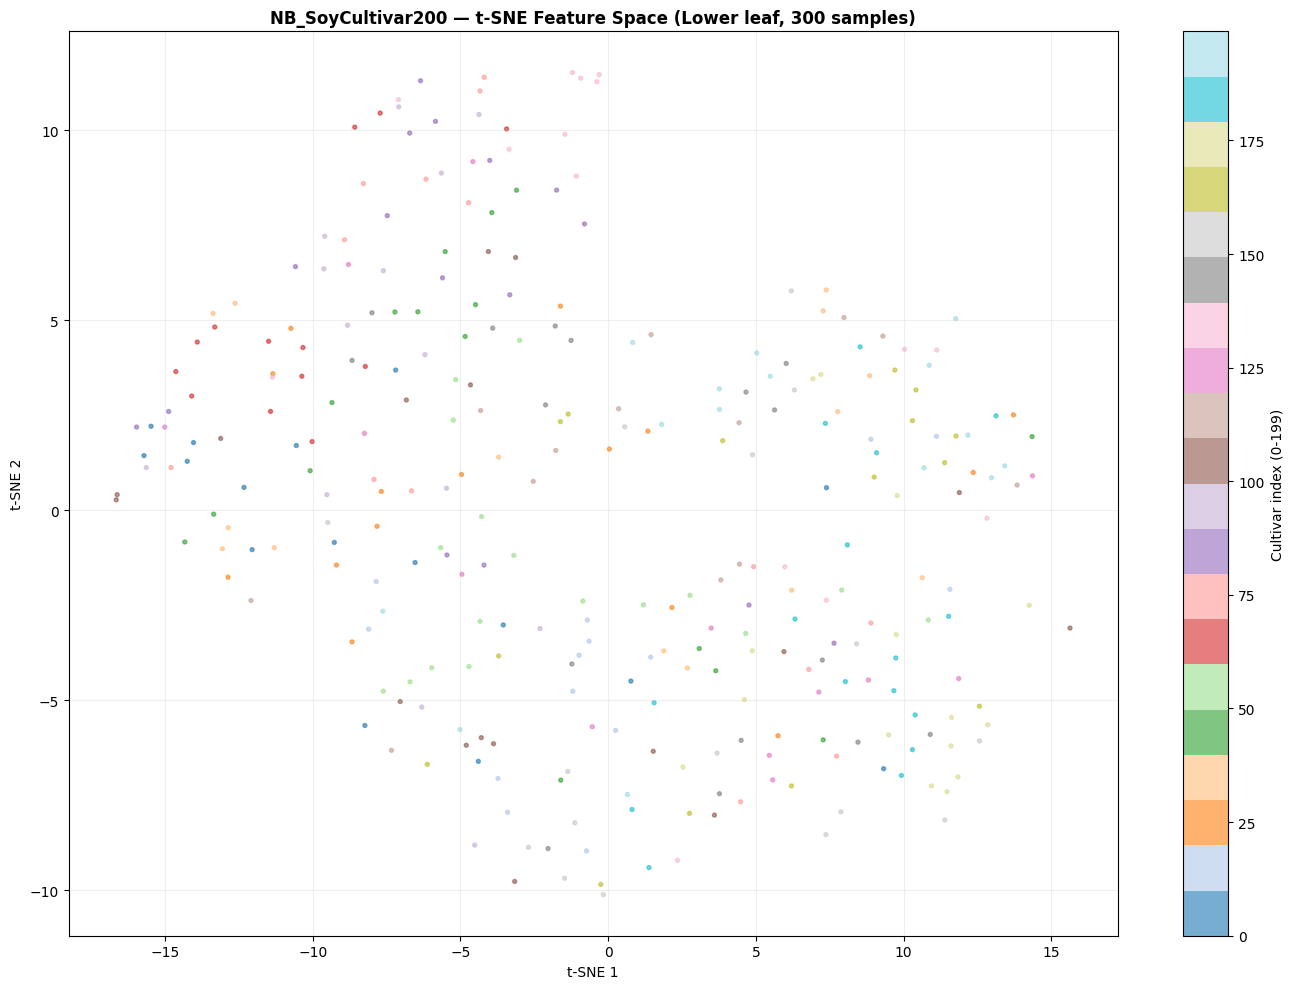

In [22]:
gap_layer_name = next(l.name for l in lower_model.layers
                      if 'gap' in l.name.lower())
gap_model = tf.keras.Model(inputs=lower_model.input,
                            outputs=lower_model.get_layer(gap_layer_name).output)

MAX_T=2000
X_sub=pL[idx_te[:MAX_T]]; y_sub=all_labels_triplet[idx_te[:MAX_T]]
ds_sub=tf.data.Dataset.from_tensor_slices((X_sub,y_sub)).map(
    lambda p,l: (tf.cast(tf.image.resize(
        tf.image.decode_image(tf.io.read_file(p),channels=3,expand_animations=False),
        IMG_SIZE),tf.float32)/255.0, l)
).batch(BATCH_SIZE).prefetch(AUTOTUNE)
feats=gap_model.predict(ds_sub,verbose=1)[:MAX_T]
lbl_s=y_sub[:len(feats)]

print('Running t-SNE on '+str(len(feats))+' samples x '+str(feats.shape[1])+' dims...')
emb=TSNE(n_components=2,perplexity=40,n_iter=1000,random_state=SEED).fit_transform(feats)

fig,ax=plt.subplots(figsize=(14,10))
sc=ax.scatter(emb[:,0],emb[:,1],c=lbl_s,cmap='tab20',s=8,alpha=0.6)
plt.colorbar(sc,ax=ax,label='Cultivar index (0-199)')
ax.set_title(NOTEBOOK_ID+' — t-SNE Feature Space (Lower leaf, '+str(len(feats))+' samples)',fontweight='bold')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2'); ax.grid(True,alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'tsne.png'),dpi=130,bbox_inches='tight')
plt.show()


ValueError: 'yerr' must not contain negative values

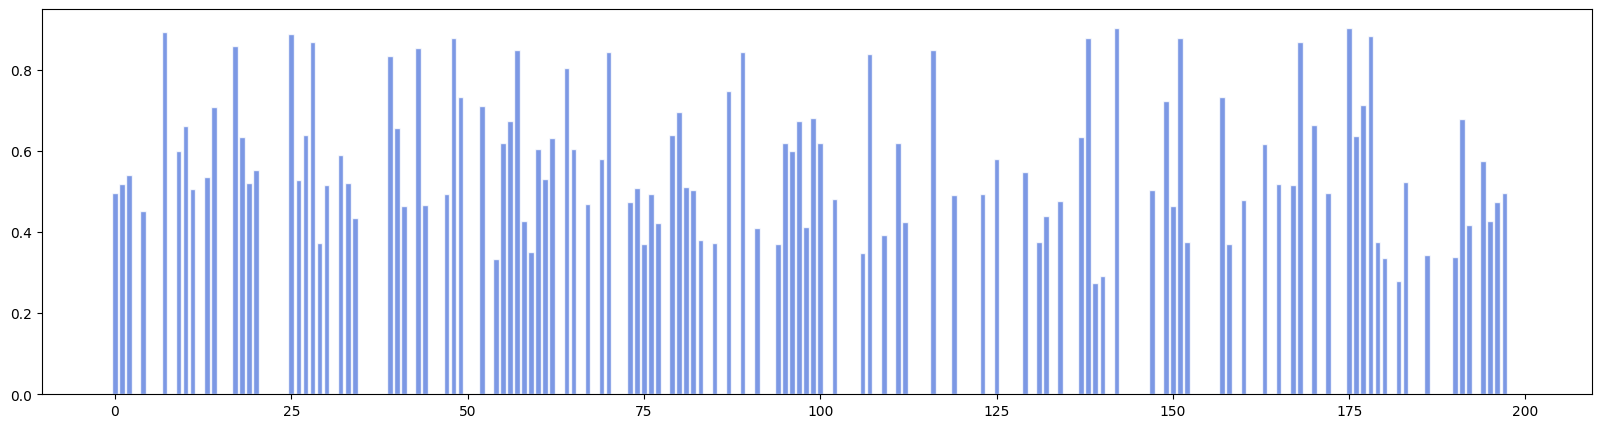

In [23]:
N_BOOT=200; boot_f1s={cls:[] for cls in TARGET_CLASSES}
rng=np.random.default_rng(SEED)
for _ in range(N_BOOT):
    idx_b=rng.choice(len(y_true),len(y_true),replace=True)
    yt_b=y_true[idx_b]; yp_b=y_pred[idx_b]
    for ci,cls in enumerate(TARGET_CLASSES):
        tp=np.sum((yt_b==ci)&(yp_b==ci))
        fp=np.sum((yt_b!=ci)&(yp_b==ci))
        fn=np.sum((yt_b==ci)&(yp_b!=ci))
        boot_f1s[cls].append((2*tp)/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0)

means=[np.mean(boot_f1s[c]) for c in TARGET_CLASSES]
ci_lo=[np.percentile(boot_f1s[c],2.5) for c in TARGET_CLASSES]
ci_hi=[np.percentile(boot_f1s[c],97.5) for c in TARGET_CLASSES]

fig,ax=plt.subplots(figsize=(20,5))
x=np.arange(NUM_CLASSES)
ax.bar(x,means,color='#5B7FDE',alpha=0.8,edgecolor='white')
ax.errorbar(x,means,yerr=[[m-l for m,l in zip(means,ci_lo)],
                            [h-m for m,h in zip(ci_hi,means)]],
            fmt='none',color='#333',capsize=2,lw=1.0)
ax.set_xticks(x[::10]); ax.set_xticklabels(TARGET_CLASSES[::10],rotation=45,ha='right',fontsize=8)
ax.set_ylim(0,1.12); ax.set_ylabel('F1-Score'); ax.grid(True,axis='y',alpha=0.3)
ax.axhline(float(np.mean(means)),color='black',ls='--',lw=1,alpha=0.5,
           label='Mean F1='+str(round(float(np.mean(means)),3)))
ax.legend(fontsize=9)
ax.set_title(NOTEBOOK_ID+' — Per-Cultivar F1 with 95% Bootstrap CI',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR,'per_class_f1_ci.png'),dpi=130,bbox_inches='tight')
plt.show()


In [ ]:
np.save(os.path.join(LOG_DIR,'y_prob.npy'),y_prob)
np.save(os.path.join(LOG_DIR,'y_true.npy'),y_true)

pd.DataFrame([{'notebook':NOTEBOOK_ID,'aug_strategy':AUG_STRATEGY,'accuracy':acc,
    'precision':prec,'recall':rec,'f1':f1,'specificity':float(np.mean(spec_list)),
    'sub_model_params':lower_model.count_params(),
    'final_model_params':final_model.count_params(),
    'total_params':3*lower_model.count_params()+final_model.count_params(),
    'model_size_mb':sz_mb,'single_inf_ms':single_ms,'per_img_batch_ms':per_img_ms,
    'peak_inf_mem_mb':inf_peak/1e6,'num_classes':NUM_CLASSES,
    'micro_auc':roc_auc_d['micro'],'macro_auc':roc_auc_d['macro'],
    'mean_ap':float(np.mean(list(pr_ap.values()))),
    'train_time_lower_min':train_time_lower/60,'train_time_middle_min':train_time_middle/60,
    'train_time_upper_min':train_time_upper/60,'train_time_final_min':train_time_final/60,
    'best_val_acc_lower':max(history_lower.history['val_accuracy']),
    'best_val_acc_middle':max(history_middle.history['val_accuracy']),
    'best_val_acc_upper':max(history_upper.history['val_accuracy']),
    'best_val_acc_final':max(history_final.history['val_accuracy'])
}]).to_csv(os.path.join(LOG_DIR,'metrics_summary.csv'),index=False)

pd.DataFrame({'class':TARGET_CLASSES,'f1_mean':means,'ci_lo':ci_lo,'ci_hi':ci_hi,
    'sensitivity':[rd[c]['recall'] for c in TARGET_CLASSES],
    'precision_cls':[rd[c]['precision'] for c in TARGET_CLASSES],
    'specificity':spec_list
}).to_csv(os.path.join(LOG_DIR,'per_class_metrics.csv'),index=False)

pd.DataFrame({'class':list(range(NUM_CLASSES))+['micro','macro'],
    'class_name':TARGET_CLASSES+['micro_avg','macro_avg'],
    'roc_auc':[roc_auc_d[i] for i in range(NUM_CLASSES)]+[roc_auc_d['micro'],roc_auc_d['macro']],
    'avg_precision':list(pr_ap.values())+[float(np.mean(list(pr_ap.values())))]*2
}).to_csv(os.path.join(LOG_DIR,'roc_auc.csv'),index=False)

with open(os.path.join(BASE_DIR,'class_mapping.json'),'w') as f:
    json.dump({'idx_to_class':IDX_TO_CLASS,'class_to_idx':CLASS_TO_IDX,
               'notebook':NOTEBOOK_ID},f,indent=2)

import shutil
dst=os.path.join('/kaggle/working','plant_project',NOTEBOOK_ID)
if os.path.exists(dst): shutil.rmtree(dst)
shutil.copytree(BASE_DIR,dst)

print(classification_report(y_true,y_pred,target_names=TARGET_CLASSES,digits=4,zero_division=0))
print('FINAL: acc='+str(round(acc,4))+' f1='+str(round(f1,4))+
      ' macro_auc='+str(round(roc_auc_d["macro"],4)))
print('All files saved to: '+VIZ_DIR)
